In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

# Activamos el autoreload para que Jupyter detecte cambios en data_utils.py
%load_ext autoreload
%autoreload 2

# Importamos nuestro módulo común personalizado
from data_utils import load_and_clean_compas, obtener_preprocesador, evaluar_rendimiento, evaluar_equidad_multivariable

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# Carga de datos 
X, y = load_and_clean_compas('./dataset/compas-scores-two-years.csv')

# División estratificada combinada (Target + Raza)
stratify_cols = y.astype(str) + X['race'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Ajuste y transformación del preprocesador numérico/categórico
preprocessor = obtener_preprocesador()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Estructura de las características de entrenamiento:", X_train.columns.tolist())

Estructura de las características de entrenamiento: ['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']


#### **Entrenamiento de modelos: Base y mitigado**

In [24]:
# 1. Modelo Baseline (Sesgado por el histórico)
print("Entrenando XGBoost base...")
xgb_base = XGBClassifier(random_state=42, n_estimators=100, max_depth=4, eval_metric='logloss')
xgb_base.fit(X_train_proc, y_train)

# 2. Modelo Curado (Mitigador con restricciones de Equalized Odds)
print("Entrenando mitigador de sesgo algorítmico...")
sensitive_train_race = X_train['race']

xgb_mitigado = ExponentiatedGradient(
    estimator=XGBClassifier(random_state=42, n_estimators=100, max_depth=4, eval_metric='logloss'),  # <--- Corregido aquí
    constraints=EqualizedOdds(),
    eps=0.01
)
xgb_mitigado.fit(X_train_proc, y_train, sensitive_features=sensitive_train_race)

print("\n=== EVALUACIÓN DE RENDIMIENTO PREDICTIVO ===")
print("\n[Modelo Base]")
_ = evaluar_rendimiento(xgb_base, X_test_proc, y_test)

print("\n[Modelo Mitigado]")
_ = evaluar_rendimiento(xgb_mitigado, X_test_proc, y_test)

Entrenando XGBoost base...
Entrenando mitigador de sesgo algorítmico...

=== EVALUACIÓN DE RENDIMIENTO PREDICTIVO ===

[Modelo Base]
--- Rendimiento del Modelo ---
Accuracy: 0.6636
F1-Score: 0.5957
AUC-ROC:  0.7167

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71      1009
           1       0.66      0.54      0.60       843

    accuracy                           0.66      1852
   macro avg       0.66      0.65      0.65      1852
weighted avg       0.66      0.66      0.66      1852


[Modelo Mitigado]
--- Rendimiento del Modelo ---
Accuracy: 0.6647
F1-Score: 0.5906
AUC-ROC:  No disponible para este mitigador (modelo estocástico).

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.66      0.78      0.72      1009
           1       0.66      0.53      0.59       843

    accuracy                           0.66      1852
   macro avg       0.66      0.65 

#### **Preparación forense multivariable**

In [25]:
# Creamos una copia local exclusivamente para estructurar las visualizaciones
X_test_audit = X_test.copy()

# Mapeo categórico temporal: Necesario para que MetricFrame pueda agrupar las métricas
def categorizar_edad_auditoria(edad):
    if edad < 25: return 'Menor de 25'
    elif edad <= 45: return '25 - 45'
    return 'Mayor de 45'

X_test_audit['age_group'] = pd.cut(
    X_test_audit['age'],
    bins=[0, 24, 45, 999],
    labels=['Menor de 25', '25 - 45', 'Mayor de 45']
).astype(str)

# Generación de variables interseccionales utilizando el nuevo grupo de edad
X_test_audit['race_sex'] = X_test_audit['race'].astype(str) + " / " + X_test_audit['sex'].astype(str)
X_test_audit['race_age'] = X_test_audit['race'].astype(str) + " / " + X_test_audit['age_group'].astype(str)

# Dimensiones finales libres de cualquier KeyError
dimensiones_a_auditar = ['race', 'sex', 'age_group', 'race_sex', 'race_age']

# Extraemos las predicciones finales de ambos estimadores
y_pred_base = xgb_base.predict(X_test_proc)
y_pred_mitigado = xgb_mitigado.predict(X_test_proc)

In [26]:
import pandas as pd
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

from functools import partial
from sklearn.metrics import precision_score

# Sustituye la función en el diccionario dentro de evaluar_equidad_multivariable
# Si no puedes tocar data_utils.py, silencia solo aquí:
import warnings
import sklearn.exceptions
warnings.filterwarnings("ignore", category=sklearn.exceptions.UndefinedMetricWarning)

gaps_globales = []

MIN_SOPORTE = 30  # umbral razonable para COMPAS

for dimension in dimensiones_a_auditar:
    # Filtro: excluir subgrupos con muy pocas muestras
    conteos = X_test_audit[dimension].value_counts()
    grupos_validos = conteos[conteos >= MIN_SOPORTE].index
    mascara = X_test_audit[dimension].isin(grupos_validos)
    
    y_test_f    = y_test[mascara]
    y_pred_b_f  = y_pred_base[mascara]
    y_pred_m_f  = y_pred_mitigado[mascara]
    grupo_f     = X_test_audit[dimension][mascara]
    
    mf_base = evaluar_equidad_multivariable(y_test_f, y_pred_b_f, grupo_f)
    mf_mit  = evaluar_equidad_multivariable(y_test_f, y_pred_m_f, grupo_f)
    
    gaps_globales.append({
        'Dimensión': dimension,
        'Grupos incluidos': list(grupos_validos),
        'Demographic Parity Gap (Base)':      demographic_parity_difference(y_test_f, y_pred_b_f, sensitive_features=grupo_f),
        'Demographic Parity Gap (Mitigado)':  demographic_parity_difference(y_test_f, y_pred_m_f, sensitive_features=grupo_f),
        'Equalized Odds Gap (Base)':          equalized_odds_difference(y_test_f, y_pred_b_f, sensitive_features=grupo_f),
        'Equalized Odds Gap (Mitigado)':      equalized_odds_difference(y_test_f, y_pred_m_f, sensitive_features=grupo_f),
    })

# Formateamos el DataFrame global resumen para tu manuscrito científico
df_resumen_gaps = pd.DataFrame(gaps_globales)
print("\n" + "="*70)
print(" RESUMEN GLOBAL DE DIFERENCIAS DE EQUIDAD (GAPS)")
print("="*70)
display(df_resumen_gaps.round(4))


 RESUMEN GLOBAL DE DIFERENCIAS DE EQUIDAD (GAPS)


,Dimensión,Grupos incluidos,Demographic Parity Gap (Base),Demographic Parity Gap (Mitigado),Equalized Odds Gap (Base),Equalized Odds Gap (Mitigado)
0,race,"[African-American, Caucasian, Hispanic, Other]",0.2856,0.1043,0.3176,0.1760
1,sex,"[Male, Female]",0.2472,0.2274,0.2517,0.2276
2,age_group,"[25 - 45, Menor de 25, Mayor de 45]",0.4425,0.3693,0.4322,0.3561
3,race_sex,"[African-American / Male, Caucasian / Male, Af...",0.4421,0.2805,0.4584,0.3623
4,race_age,"[African-American / 25 - 45, Caucasian / 25 - ...",0.6318,0.4605,0.6823,0.6235


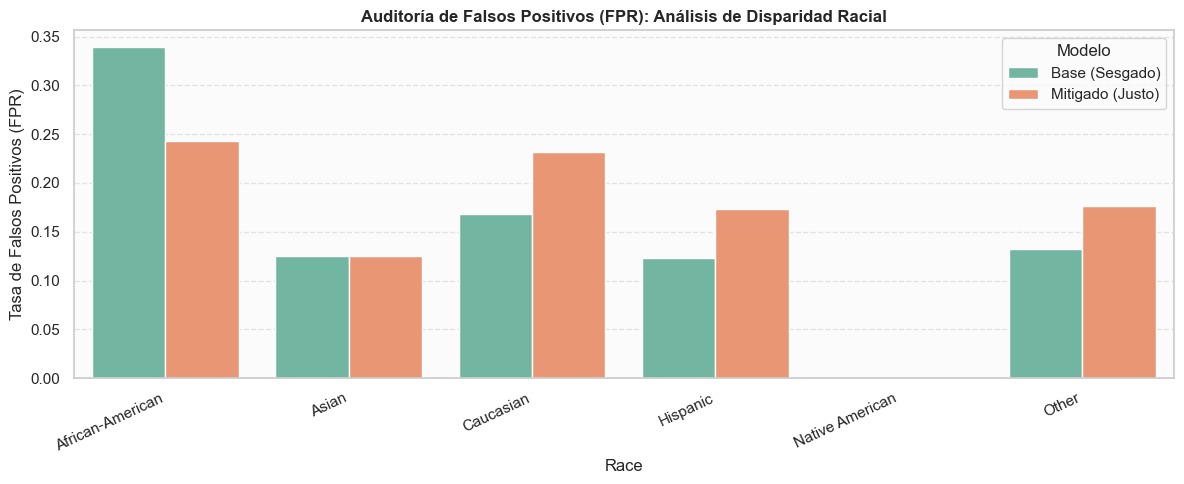

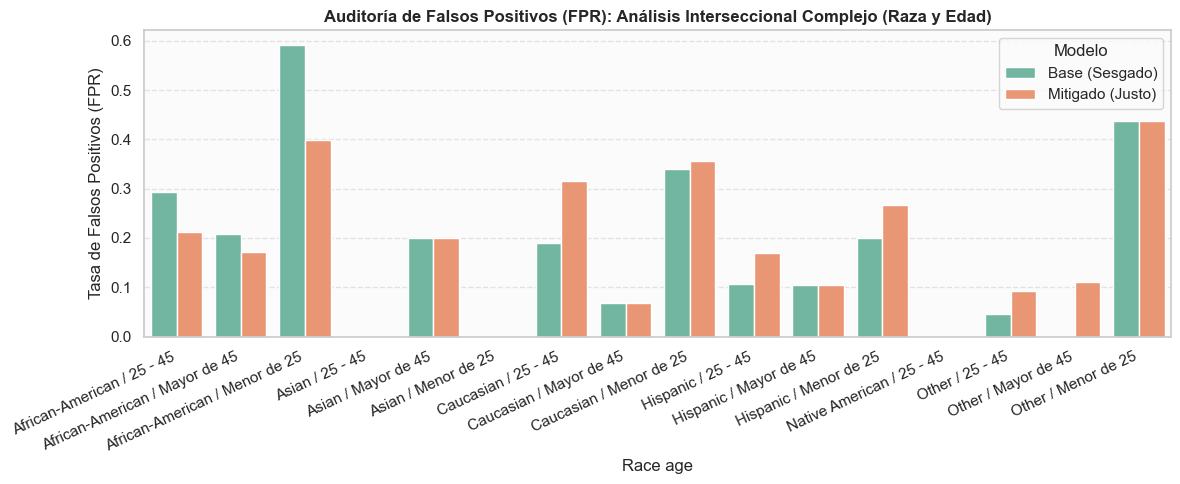

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_comparativa_fpr(columna, titulo):
    mf_base = evaluar_equidad_multivariable(y_test, y_pred_base, X_test_audit[columna])
    mf_mit = evaluar_equidad_multivariable(y_test, y_pred_mitigado, X_test_audit[columna])
    
    df_plot = pd.DataFrame({
        'FPR': list(mf_base.by_group['FPR (Falsos Positivos)']) + list(mf_mit.by_group['FPR (Falsos Positivos)']),
        'Subgrupo': list(mf_base.by_group.index) + list(mf_mit.by_group.index),
        'Modelo': ['Base (Sesgado)'] * len(mf_base.by_group) + ['Mitigado (Justo)'] * len(mf_mit.by_group)
    })
    
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_plot, x='Subgrupo', y='FPR', hue='Modelo', palette='Set2')
    plt.title(f'Auditoría de Falsos Positivos (FPR): {titulo}', fontsize=12, fontweight='bold')
    plt.ylabel('Tasa de Falsos Positivos (FPR)')
    plt.xlabel(columna.replace('_', ' ').capitalize())
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.show()

# Lanzamos las dos gráficas analíticas principales
graficar_comparativa_fpr('race', 'Análisis de Disparidad Racial')
graficar_comparativa_fpr('race_age', 'Análisis Interseccional Complejo (Raza y Edad)')

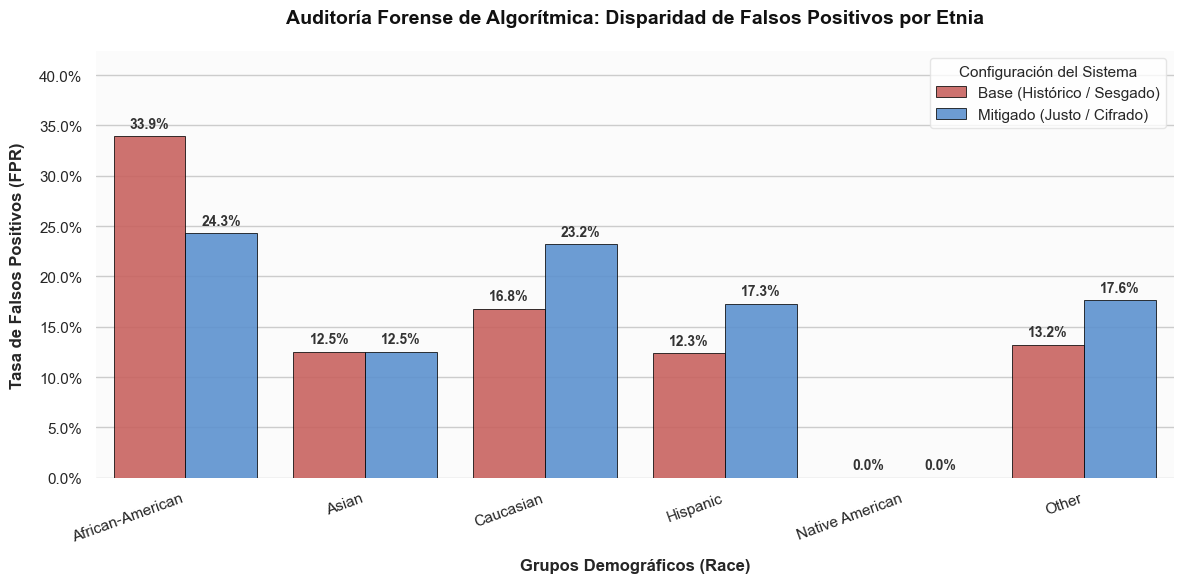

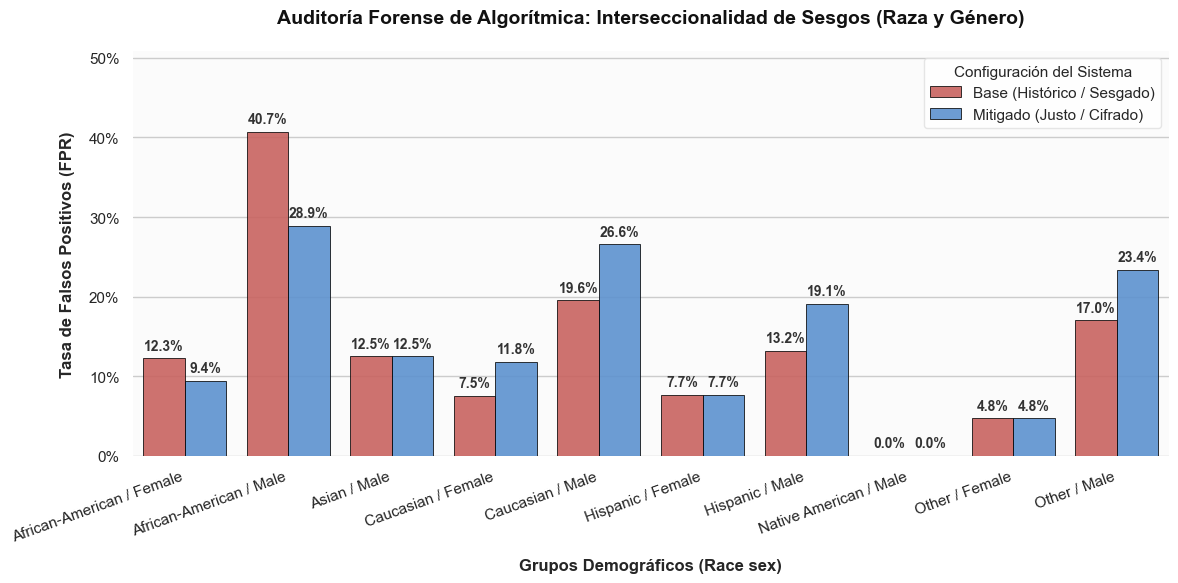

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from data_utils import evaluar_equidad_multivariable

def graficar_comparativa_fpr_premium(columna, titulo_limpio, dataframe_audit, y_test, y_pred_base, y_pred_mitigado):
    """Genera una gráfica de barras de alta calidad con etiquetas de datos para el FPR."""
    # 1. Configuración del estilo científico y tipografía limpia
    sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#fbfbfb", "figure.facecolor": "#ffffff"})
    plt.rcParams['font.family'] = 'sans-serif'
    
    # 2. Extracción y estructuración de los datos de Fairlearn
    mf_base = evaluar_equidad_multivariable(y_test, y_pred_base, dataframe_audit[columna])
    mf_mit = evaluar_equidad_multivariable(y_test, y_pred_mitigado, dataframe_audit[columna])
    
    df_plot = pd.DataFrame({
        'FPR': list(mf_base.by_group['FPR (Falsos Positivos)']) + list(mf_mit.by_group['FPR (Falsos Positivos)']),
        'Subgrupo': list(mf_base.by_group.index) + list(mf_mit.by_group.index),
        'Modelo': ['Base (Histórico / Sesgado)'] * len(mf_base.by_group) + ['Mitigado (Justo / Cifrado)'] * len(mf_mit.by_group)
    })
    
    # 3. Creación del lienzo
    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    
    # Paleta intencional: Rojo carmín suave para el sesgo, Azul acero para la equidad
    paleta_premium = {'Base (Histórico / Sesgado)': '#d9534f', 'Mitigado (Justo / Cifrado)': '#4A90E2'}
    
    barplot = sns.barplot(
        data=df_plot, 
        x='Subgrupo', 
        y='FPR', 
        hue='Modelo', 
        palette=paleta_premium,
        edgecolor='black',
        linewidth=0.6,
        alpha=0.9,
        ax=ax
    )
    
    # 4. Inserción de etiquetas numéricas sobre cada barra de forma limpia
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt=lambda x: f'{x:.1%}', 
            label_type='edge', 
            padding=4, 
            fontsize=10, 
            fontweight='bold',
            color='#333333'
        )
    
    # 5. Pulido de ejes y títulos explicativos
    nombre_eje_x = columna.replace('_', ' ').capitalize()
    ax.set_title(f'Auditoría Forense de Algorítmica: {titulo_limpio}', fontsize=14, fontweight='bold', pad=20, color='#111111')
    ax.set_ylabel('Tasa de Falsos Positivos (FPR)', fontsize=12, labelpad=10, fontweight='semibold')
    ax.set_xlabel(f'Grupos Demográficos ({nombre_eje_x})', fontsize=12, labelpad=10, fontweight='semibold')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
    
    # Multiplicamos el eje Y conceptualmente para que la escala sea más intuitiva (0 a 1 -> 0% a 100%)
    ax.set_ylim(0, max(df_plot['FPR']) * 1.25) # Margen superior para las etiquetas
    
    # Ajustes estéticos finales de la leyenda y los bordes
    ax.legend(title='Configuración del Sistema', title_fontsize='11', loc='upper right', frameon=True, facecolor='white', edgecolor='#e0e0e0')
    sns.despine(left=True, bottom=True)
    
    plt.xticks(rotation=20, ha='right', fontsize=11)
    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
# Gráfica 1: El eje central de la controversia (Raza)
graficar_comparativa_fpr_premium('race', 'Disparidad de Falsos Positivos por Etnia', X_test_audit, y_test, y_pred_base, y_pred_mitigado)

# Gráfica 2: Análisis Interseccional Complejo (Raza / Género)
graficar_comparativa_fpr_premium('race_sex', 'Interseccionalidad de Sesgos (Raza y Género)', X_test_audit, y_test, y_pred_base, y_pred_mitigado)

In [29]:
def graficar_reduccion_gap_global(df_gaps_calculados):
    """Genera un gráfico de líneas y puntos de alta gama para mostrar la contracción de la injusticia."""
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="whitegrid")
    
    # Ordenamos de mayor a menor sesgo original para facilitar la narrativa visual
    df_sorted = df_gaps_calculados.sort_values(by='Equalized Odds Gap (Base)', ascending=True)
    
    plt.figure(figsize=(10, 5), dpi=100)
    ax = plt.subplot(111)
    
    # Dibujamos las líneas conectoras (el "camino" de la mitigación)
    plt.hlines(
        y=df_sorted['Dimensión'].str.replace('_', ' ').str.upper(), 
        xmin=df_sorted['Equalized Odds Gap (Mitigado)'], 
        xmax=df_sorted['Equalized Odds Gap (Base)'], 
        color='#cccccc', 
        linewidth=3, 
        alpha=0.6,
        zorder=1
    )
    
    # CORREGIDO: Se cambia size=120 por s=120
    # Dibujamos los puntos del Estado Inicial (Sesgado)
    plt.scatter(
        df_sorted['Equalized Odds Gap (Base)'], 
        df_sorted['Dimensión'].str.replace('_', ' ').str.upper(), 
        color='#d9534f', 
        s=120, 
        label='XGBoost Original (Sesgado)', 
        edgecolor='black',
        linewidth=0.7,
        zorder=2
    )
    
    # CORREGIDO: Se cambia size=120 por s=120
    # Dibujamos los puntos del Estado Final (Mitigado)
    plt.scatter(
        df_sorted['Equalized Odds Gap (Mitigado)'], 
        df_sorted['Dimensión'].str.replace('_', ' ').str.upper(), 
        color='#5cb85c', 
        s=120, 
        label='Gradiente Exponencial (Justo)', 
        edgecolor='black',
        linewidth=0.7,
        zorder=3
    )
    
    # Línea de referencia ideal (0.00 = Equidad matemática perfecta)
    plt.axvline(x=0, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.7, label='Paridad Perfecta (Meta)')
    
    # Títulos y formato
    plt.title('Efecto del Algoritmo de Mitigación en el Gap de Equalized Odds', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Magnitud de la Disparidad (Gap Global)', fontsize=11, fontweight='semibold')
    plt.ylabel('Dimensiones Auditadas', fontsize=11, fontweight='semibold')
    
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0')
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

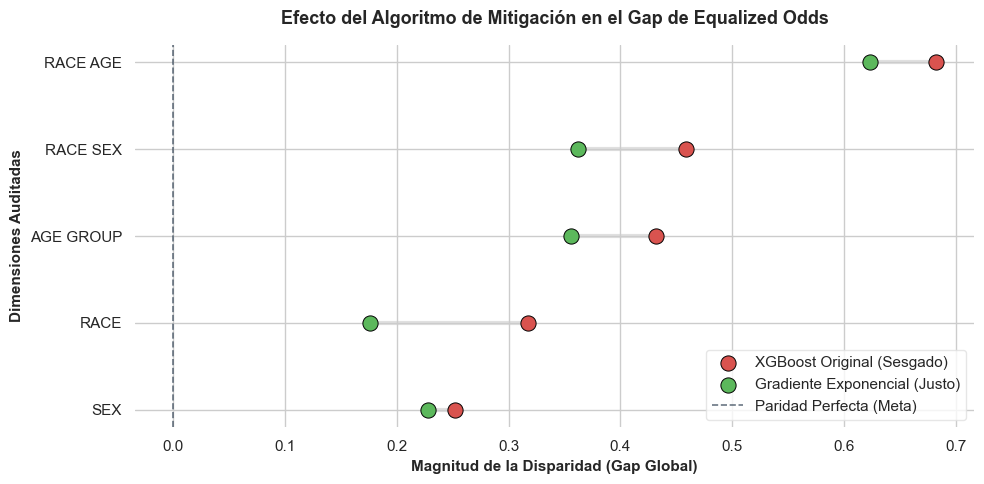

In [30]:
# --- EJECUCIÓN ---
# Pasamos el dataframe de gaps resumidos que calcula tu Celda 4
graficar_reduccion_gap_global(df_resumen_gaps)